In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
playing_time_against = pd.read_csv(
    r"../data/overwiev__stats_squads_playing_time_against.csv"
)

playing_time_against.head()

,Squad,# Pl,Age,Playing Time_MP,Playing Time_Min,Playing Time_Mn/MP,Playing Time_Min%,Playing Time_90s,Starts_Starts,Starts_Mn/Start,Starts_Compl,Subs_Subs,Subs_Mn/Sub,Subs_unSub,Team Success_PPM,Team Success_onG,Team Success_onGA,Team Success_+/-,Team Success_+/-90
0,vs Arsenal,25,26.1,38,3420,90,100,38.0,418,83,259,157,21,185,0.68,34,69,-35,-0.92
1,vs Aston Villa,28,26.3,38,3420,90,100,38.0,418,80,263,157,18,185,1.03,51,58,-7,-0.18
2,vs Bournemouth,29,26.4,38,3420,90,100,38.0,418,83,254,160,20,182,1.24,46,58,-12,-0.32
3,vs Brentford,28,26.4,38,3420,90,100,38.0,418,85,251,165,20,177,1.32,57,66,-9,-0.24
4,vs Brighton,32,26.2,38,3420,90,100,38.0,418,82,254,163,20,179,1.05,59,66,-7,-0.18


In [3]:
playing_time_against.columns

Index(['Squad', '# Pl', 'Age', 'Playing Time_MP', 'Playing Time_Min',
       'Playing Time_Mn/MP', 'Playing Time_Min%', 'Playing Time_90s',
       'Starts_Starts', 'Starts_Mn/Start', 'Starts_Compl', 'Subs_Subs',
       'Subs_Mn/Sub', 'Subs_unSub', 'Team Success_PPM', 'Team Success_onG',
       'Team Success_onGA', 'Team Success_+/-', 'Team Success_+/-90'],
      dtype='str')

In [4]:
playing_time_against = playing_time_against.rename(columns={
    "Squad": "team",
    "# Pl": "players_faced",
    "Subs_Subs": "subs_against"
})

playing_time_against["team"] = playing_time_against["team"].str.strip()

playing_time_against.head()

,team,players_faced,Age,Playing Time_MP,Playing Time_Min,Playing Time_Mn/MP,Playing Time_Min%,Playing Time_90s,Starts_Starts,Starts_Mn/Start,Starts_Compl,subs_against,Subs_Mn/Sub,Subs_unSub,Team Success_PPM,Team Success_onG,Team Success_onGA,Team Success_+/-,Team Success_+/-90
0,vs Arsenal,25,26.1,38,3420,90,100,38.0,418,83,259,157,21,185,0.68,34,69,-35,-0.92
1,vs Aston Villa,28,26.3,38,3420,90,100,38.0,418,80,263,157,18,185,1.03,51,58,-7,-0.18
2,vs Bournemouth,29,26.4,38,3420,90,100,38.0,418,83,254,160,20,182,1.24,46,58,-12,-0.32
3,vs Brentford,28,26.4,38,3420,90,100,38.0,418,85,251,165,20,177,1.32,57,66,-9,-0.24
4,vs Brighton,32,26.2,38,3420,90,100,38.0,418,82,254,163,20,179,1.05,59,66,-7,-0.18


In [5]:
playing_time_against["opponent_rotation"] = (
    playing_time_against["players_faced"] /
    playing_time_against["Playing Time_MP"]
)

playing_time_against[[
    "team",
    "players_faced",
    "opponent_rotation"
]].head()

,team,players_faced,opponent_rotation
0,vs Arsenal,25,0.657895
1,vs Aston Villa,28,0.736842
2,vs Bournemouth,29,0.763158
3,vs Brentford,28,0.736842
4,vs Brighton,32,0.842105


In [6]:
defensive_pressure = playing_time_against.sort_values(
    by="opponent_rotation",
    ascending=False
)

defensive_pressure[[
    "team",
    "opponent_rotation"
]]

,team,opponent_rotation
16,vs Southampton,0.947368
9,vs Ipswich Town,0.842105
4,vs Brighton,0.842105
10,vs Leicester City,0.842105
19,vs Wolves,0.842105
13,vs Manchester Utd,0.815789
17,vs Tottenham Hotspur,0.815789
12,vs Manchester City,0.789474
5,vs Chelsea,0.763158
6,vs Crystal Palace,0.763158


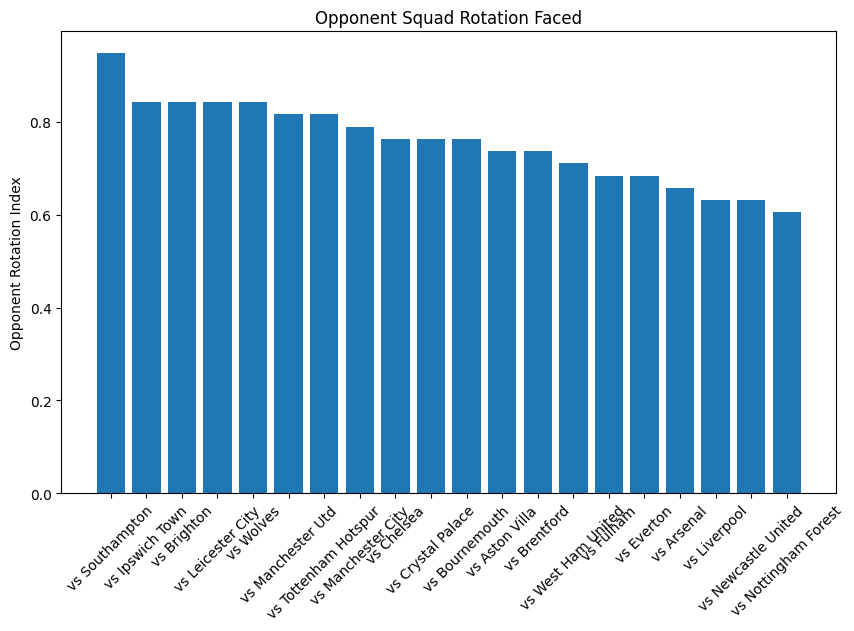

In [7]:
plt.figure(figsize=(10,6))

plt.bar(
    defensive_pressure["team"],
    defensive_pressure["opponent_rotation"]
)

plt.xticks(rotation=45)
plt.ylabel("Opponent Rotation Index")
plt.title("Opponent Squad Rotation Faced")

plt.show()

In [8]:
playing_time_against["opponent_sub_intensity"] = (
    playing_time_against["subs_against"] /
    playing_time_against["Playing Time_MP"]
)

playing_time_against[[
    "team",
    "opponent_sub_intensity"
]].head()

,team,opponent_sub_intensity
0,vs Arsenal,4.131579
1,vs Aston Villa,4.131579
2,vs Bournemouth,4.210526
3,vs Brentford,4.342105
4,vs Brighton,4.289474


In [9]:
opponent_sub_rank = playing_time_against.sort_values(
    by="opponent_sub_intensity",
    ascending=False
)

opponent_sub_rank[[
    "team",
    "opponent_sub_intensity"
]]

,team,opponent_sub_intensity
16,vs Southampton,4.421053
19,vs Wolves,4.368421
3,vs Brentford,4.342105
10,vs Leicester City,4.342105
4,vs Brighton,4.289474
18,vs West Ham United,4.263158
9,vs Ipswich Town,4.263158
15,vs Nottingham Forest,4.263158
14,vs Newcastle United,4.236842
12,vs Manchester City,4.236842


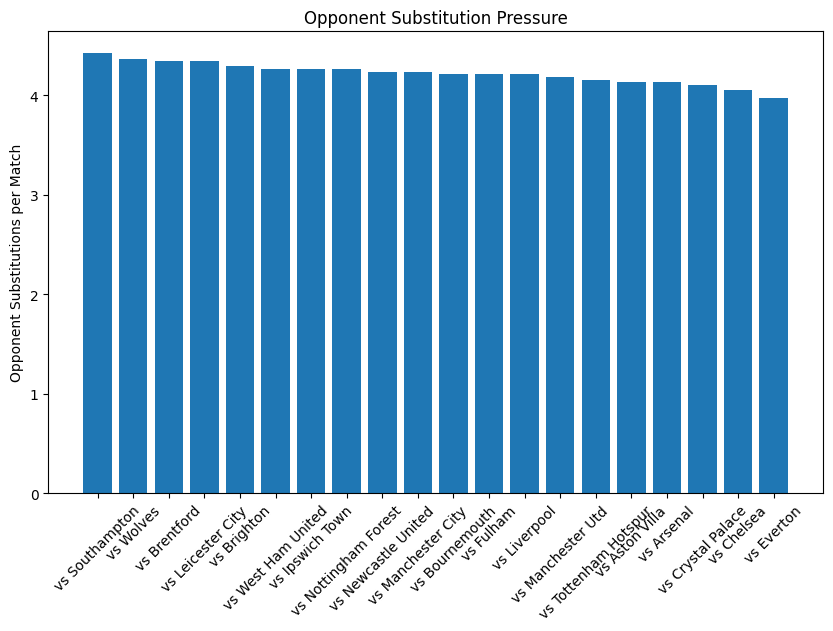

In [10]:
plt.figure(figsize=(10,6))

plt.bar(
    opponent_sub_rank["team"],
    opponent_sub_rank["opponent_sub_intensity"]
)

plt.xticks(rotation=45)
plt.ylabel("Opponent Substitutions per Match")
plt.title("Opponent Substitution Pressure")

plt.show()

In [11]:
playing_time_against["defensive_fatigue_index"] = (
    playing_time_against["opponent_rotation"] +
    playing_time_against["opponent_sub_intensity"]
)

In [12]:
fatigue_rank = playing_time_against.sort_values(
    by="defensive_fatigue_index",
    ascending=False
)

fatigue_rank[[
    "team",
    "defensive_fatigue_index"
]]

,team,defensive_fatigue_index
16,vs Southampton,5.368421
19,vs Wolves,5.210526
10,vs Leicester City,5.184211
4,vs Brighton,5.131579
9,vs Ipswich Town,5.105263
3,vs Brentford,5.078947
12,vs Manchester City,5.026316
13,vs Manchester Utd,5.000000
18,vs West Ham United,4.973684
17,vs Tottenham Hotspur,4.973684


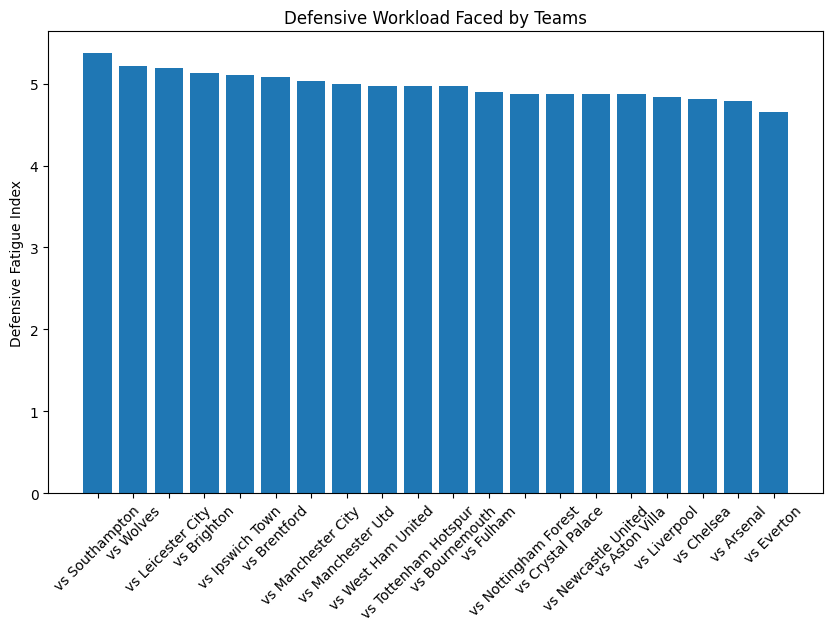

In [13]:
plt.figure(figsize=(10,6))

plt.bar(
    fatigue_rank["team"],
    fatigue_rank["defensive_fatigue_index"]
)

plt.xticks(rotation=45)
plt.ylabel("Defensive Fatigue Index")
plt.title("Defensive Workload Faced by Teams")

plt.show()